# Exp 5: all-fish position-map raster

This is the maintained all-fish raster workflow for `Exp_5_map_positions`. It uses the shared `src` helpers to load the validated Exp 5 cohort, build z-score rasters and mean traces, and inspect left/right activity. The experiment-specific cohort, timing, and stimulus order are defined in the settings cell.

In [1]:
# Cell 01 - Setup
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.analysis_tools as at
import src.multifish_analysis as mfa
import src.plotting as plott
plott = importlib.reload(plott)
import src.reusable_several_fish as rsf
rsf = importlib.reload(rsf)


In [2]:
# Cell 02 - Exp 5 settings
# Cohort, stimulus IDs, and timing were taken from Exp5_map_positions_several.ipynb.
USER_SETTINGS = {
    'experiment_name': 'Exp_5_map_positions',
    'analysis_label': 'Exp 5 map positions',
    'data_base': Path(r'D:\\Alejandro\\Data'),
    # Maintained cohort with complete significant-raster and kept-neuron caches.
    'fish_ids': ['L684_f01', 'L684_f07', 'L733_f01', 'L733_f06', 'L733_f07'],
    'selected_blocks': [f'B{number}' for number in range(1, 5)],
    'verbose_loading': False,
    'timing': {'fps_2p': 2.0, 't_pre_s': 5.0, 't_post_s': 25.0, 'motion_onset_s': 8.0, 'tau_s': 6.0},
    # Left controls/positions/flicker/rocking, followed by the matched right stimuli.
    'stim_order': [7, 3, 4, 5, 6, 1, 13, 12, 8, 9, 10, 11, 2, 14],
    'combine_mode': 'mean',
    'trace_type': 'zscore',
    'raster_sort_mode': 'left_right_index',
    'left_control': 7,   # LeBcontrol
    'right_control': 12, # RiBcontrol
}

REPORT_SETTINGS = {
    'save_report': False,
    'run_label': 'exp5_map_positions_all_fish_raster',
    'report_format': 'html',
    'export_notebook': True,
    'fallback_to_html': True,
    'comments': 'Enable only after reviewing the Exp 5 figures.',
}


In [3]:
# Cell 03 - Load the selected Exp 5 cohort and validate every configured stimulus ID.
raster_inputs = rsf.load_and_preflight_fish_raster_inputs(USER_SETTINGS)
globals().update(raster_inputs)
stimuli_colors, stimuli_linestyles = plott.build_stimulus_style_maps(stimuli_names=stimuli_names)
print('Detected Exp 5 stimulus map:', stimuli_id_map)


Detected Exp 5 stimulus map: {'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}


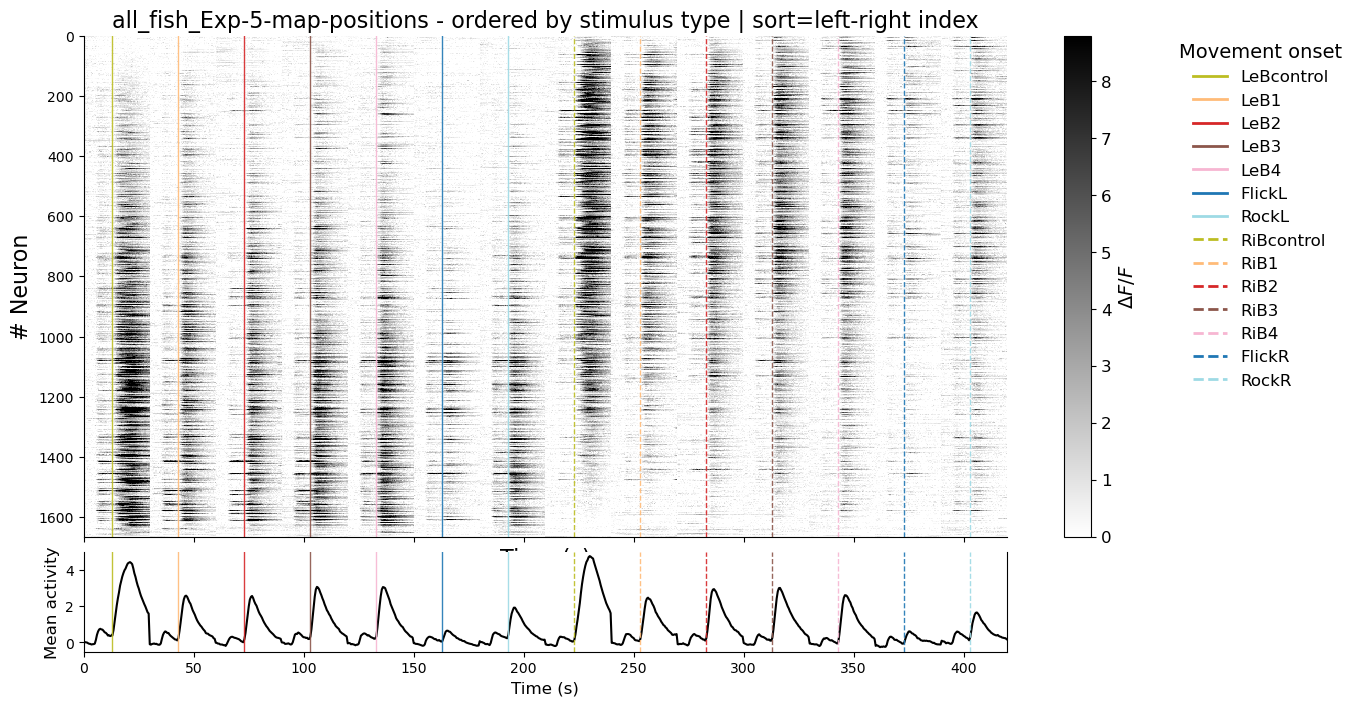

In [4]:
# Cell 04 - All-fish z-score raster.
FIGSIZE = (13, 8)
raster_result = rsf.build_all_fish_raster_figure(
    all_fish_data, fish_ids, stim_order, reference_fish, timing, settings,
    stimuli_colors, stimuli_linestyles, figsize=FIGSIZE,
)
flat_matrix_all_fish = raster_result['flat_matrix_all_fish']
plt.show()


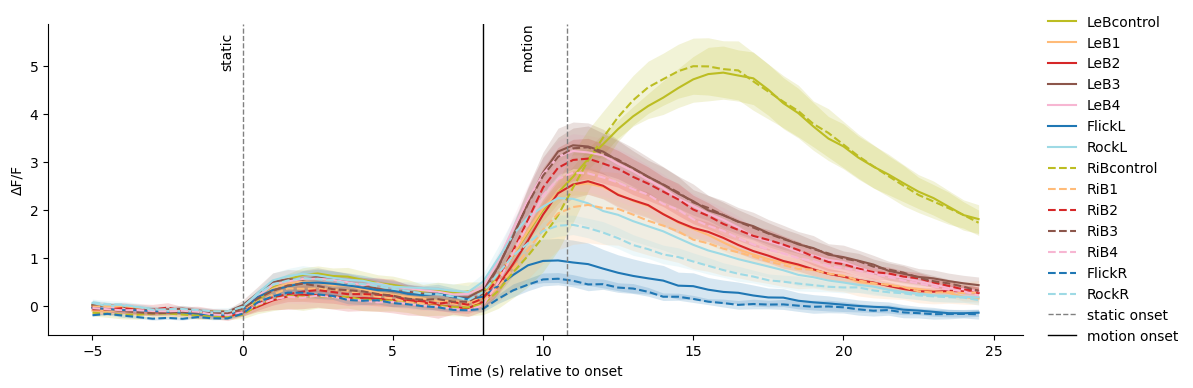

In [5]:
# Cell 05 - Mean z-score traces in the configured Exp 5 stimulus order.
FIGSIZE = (12, 4)
mean_trace_result = rsf.build_plot_all_fish_mean_zscore_traces(
    all_fish_data, fish_ids, stim_order, reference_fish, timing,
    stimuli_colors, stimuli_linestyles, figsize=FIGSIZE,
)


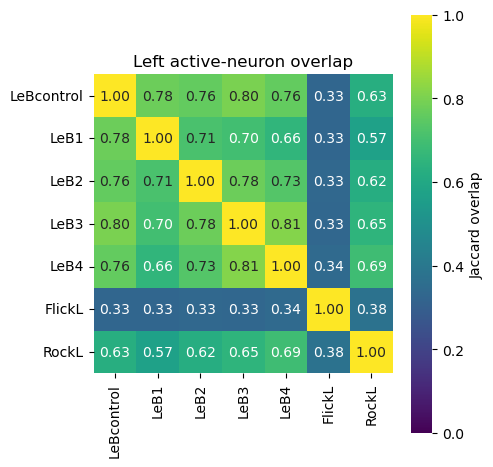

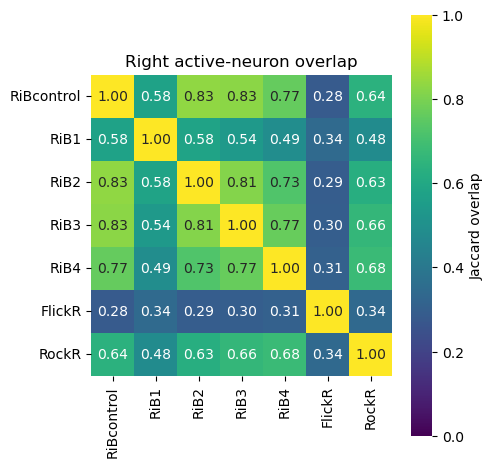

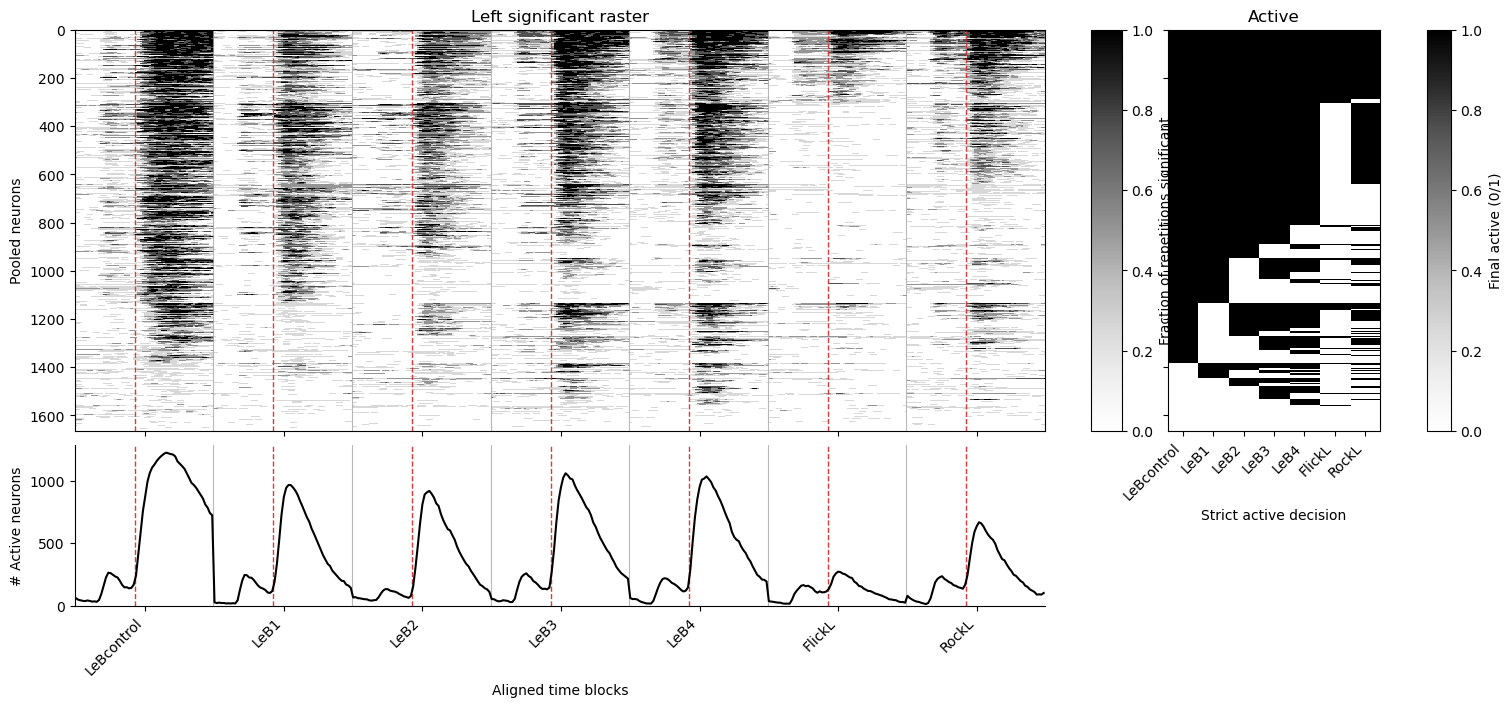

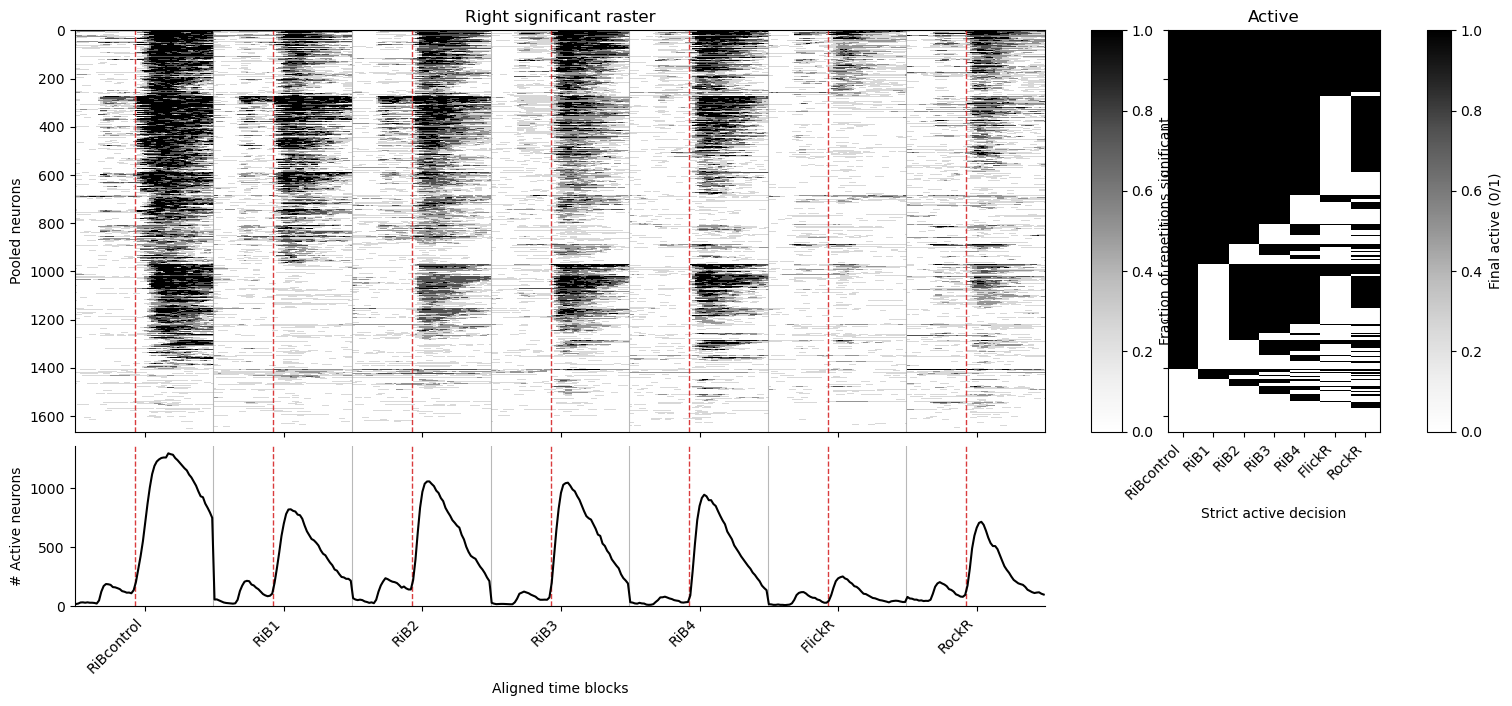

In [6]:
# Cell 06 - Left/right active-neuron overlap and significant-raster diagnostics.
OVERLAP_FIGSIZE = (5, 5)
RASTER_FIGSIZE = (16, 8)
OVERLAP_STIMULI = {
    'left': [7, 3, 4, 5, 6, 1, 13],
    'right': [12, 8, 9, 10, 11, 2, 14],
}
overlap_results = rsf.plot_left_right_active_overlap_diagnostics(
    all_fish_data, fish_ids, reference_fish, timing, OVERLAP_STIMULI,
    motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    show_overlap=True, show_significant_raster=False, overlap_figsize=OVERLAP_FIGSIZE,
    raster_figsize=RASTER_FIGSIZE,
)
for side in ('left', 'right'):
    diagnostic_data = overlap_results[side]
    diagnostic = diagnostic_data['active_trace_diagnostic']
    if diagnostic['trace_matrix'].shape[0] == 0:
        print(f'No active neurons passed the {side} settings.')
        continue
    plott.plot_active_trace_decision_diagnostic(
        diagnostic, fps_2p=timing['fps_2p'], stimuli_durations=reference_fish['stimuli_durations'],
        t_pre_s=timing['t_pre_s'], sort_mode=None,
        neuron_order=diagnostic_data['diagnostic_neuron_order'], trace_cmap='Greys',
        trace_title=f'{side.capitalize()} significant raster', show_active_count_trace=True,
        active_count_threshold=0.5, active_count_color='black', active_count_ylabel='# Active neurons',
        active_count_height_ratio=2.4, figsize=RASTER_FIGSIZE,
    )
    plt.show()


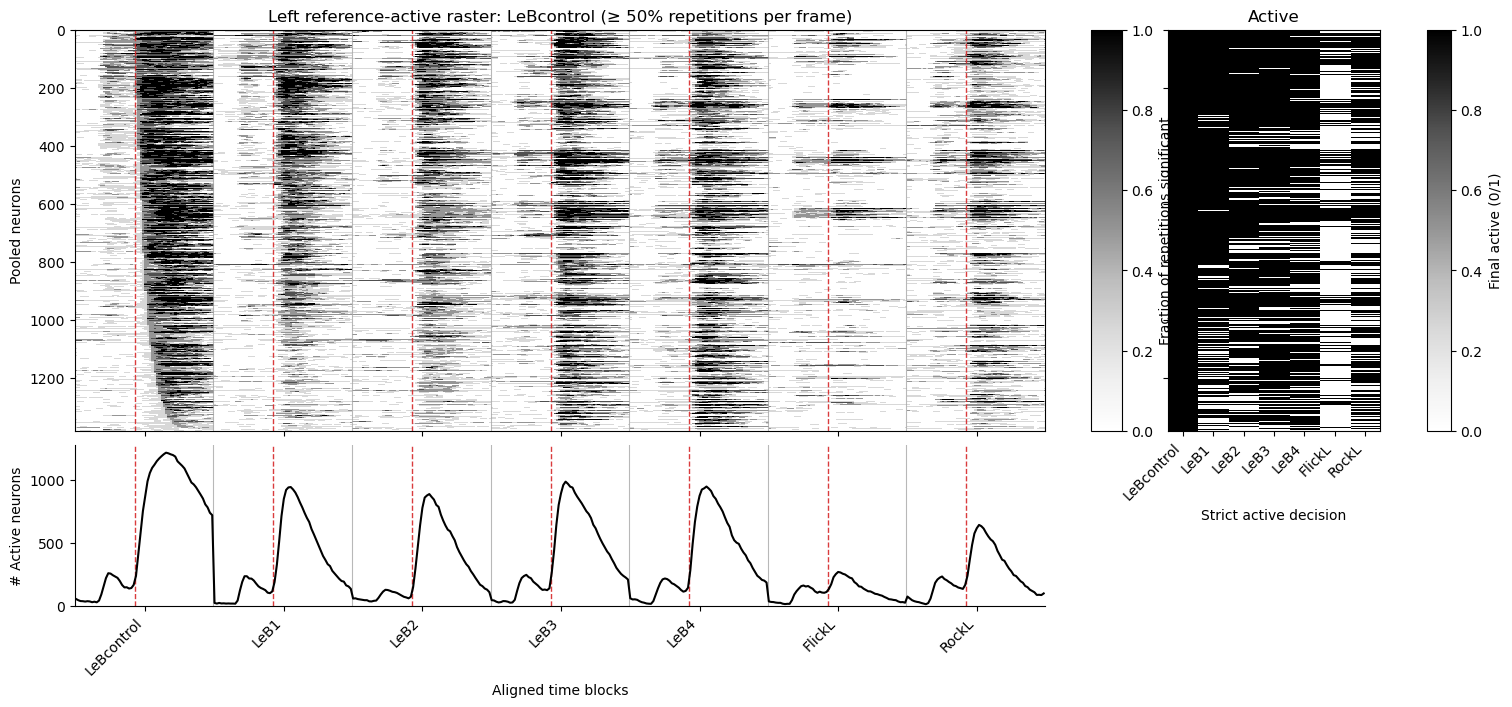

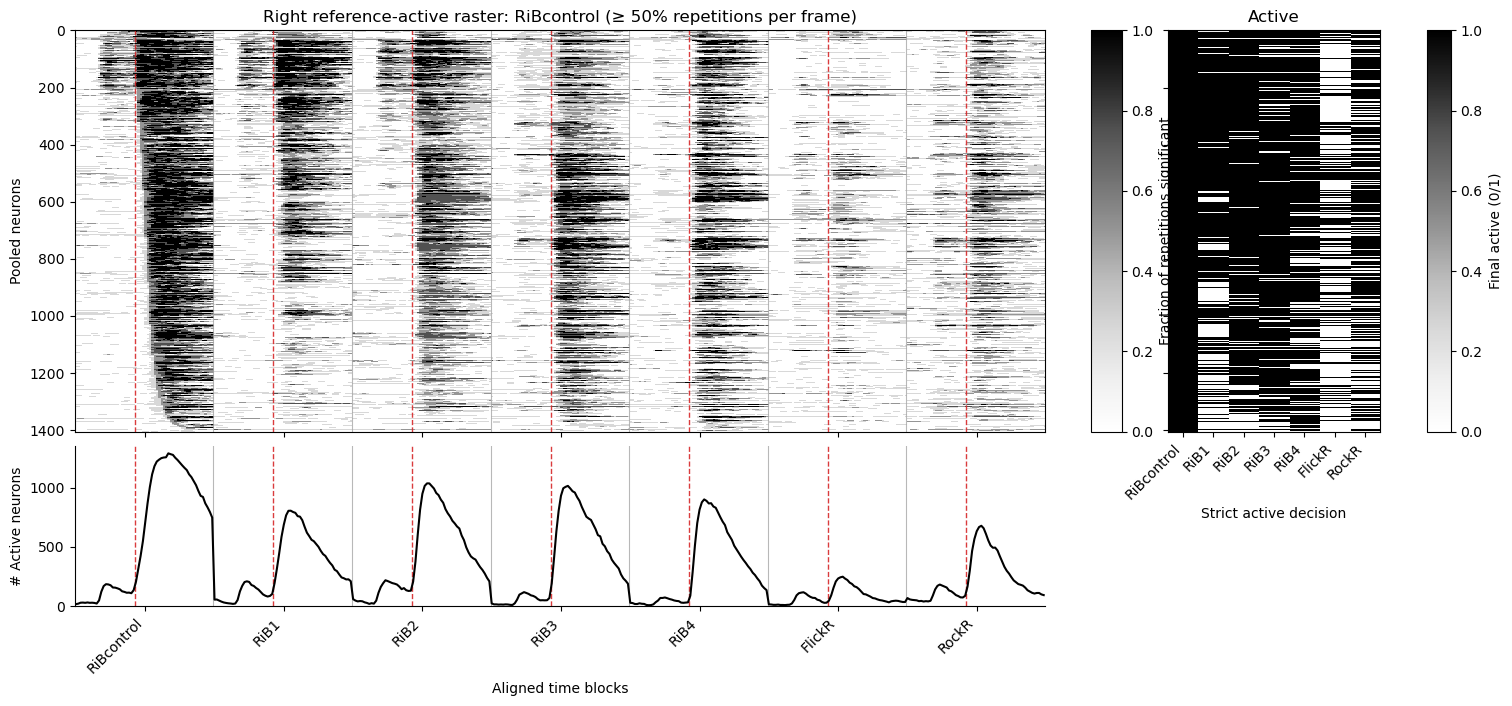

In [7]:
# Cell 07 - Reference-active significant rasters, ordered by post-motion onset.
REFERENCE_RASTER_SETTINGS = {
    'left': {'reference_stimulus': 7, 'plot_stimuli': [7, 3, 4, 5, 6, 1, 13]},
    'right': {'reference_stimulus': 12, 'plot_stimuli': [12, 8, 9, 10, 11, 2, 14]},
}
min_active_reps = 0.50

reference_and_plot_stimuli = list(dict.fromkeys(
    [group['reference_stimulus'] for group in REFERENCE_RASTER_SETTINGS.values()]
    + [stimulus for group in REFERENCE_RASTER_SETTINGS.values() for stimulus in group['plot_stimuli']]
))
reference_active_matrices = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data, fish_ids=fish_ids, stim_order=reference_and_plot_stimuli,
    fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'],
    motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    active_fraction_threshold=0.10, min_epoch_s=1.0, min_active_reps=2,
    expected_reps=4, require_expected_reps=True,
)

for side, group in REFERENCE_RASTER_SETTINGS.items():
    selection = at.resolve_selected_stimuli(group['plot_stimuli'], reference_fish['stimuli_id_map'],
                                             reference_fish['trial_aligned_traces_raster'].keys())
    reference_selection = at.resolve_selected_stimuli([group['reference_stimulus']], reference_fish['stimuli_id_map'],
                                                       reference_fish['trial_aligned_traces_raster'].keys())
    reference_id = reference_selection['stimulus_ids'][0]
    reference_label = reference_selection['stimulus_labels'][0]
    diagnostic = mfa.build_pooled_active_trace_diagnostic(
        all_fish_data=all_fish_data, active_matrices=reference_active_matrices, fish_ids=fish_ids,
        stim_order=selection['stimulus_ids'], combine_mode='mean', trial_key='trial_aligned_traces_raster',
    )
    activity_onsets = []
    for fish_id in fish_ids:
        fish = all_fish_data[fish_id]
        reference_key = reference_id if reference_id in fish['trial_aligned_traces_raster'] else str(reference_id)
        reference_raster = np.asarray(fish['trial_aligned_traces_raster'][reference_key], dtype=bool)
        duration = fish['stimuli_durations'][reference_label]
        motion_frame = int(np.clip(round((timing['t_pre_s'] + duration['static_before_sec']) * timing['fps_2p']),
                                   0, reference_raster.shape[1] - 1))
        active_by_frame = reference_raster.mean(axis=2) >= min_active_reps
        post_motion = active_by_frame[:, motion_frame:]
        first_active = np.full(reference_raster.shape[0], np.inf)
        has_active_frame = post_motion.any(axis=1)
        first_active[has_active_frame] = motion_frame + post_motion[has_active_frame].argmax(axis=1)
        activity_onsets.append(first_active)
    activity_onsets = np.concatenate(activity_onsets)
    reference_active = diagnostic['row_metadata'].apply(
        lambda row: bool(reference_active_matrices[row['fish_id']].loc[row['neuron_id'], reference_id]), axis=1
    ).to_numpy()
    keep_rows = np.flatnonzero(reference_active)
    if keep_rows.size == 0:
        print(f'No neurons are strictly active for {side} reference {reference_label}.')
        continue
    selected_diagnostic = {**diagnostic, 'trace_matrix': diagnostic['trace_matrix'][keep_rows],
                           'decision_matrix': diagnostic['decision_matrix'][keep_rows],
                           'row_metadata': diagnostic['row_metadata'].iloc[keep_rows].reset_index(drop=True)}
    onset_order = np.argsort(activity_onsets[keep_rows], kind='stable')
    plott.plot_active_trace_decision_diagnostic(
        selected_diagnostic, fps_2p=timing['fps_2p'], stimuli_durations=reference_fish['stimuli_durations'],
        t_pre_s=timing['t_pre_s'], sort_mode=None, neuron_order=onset_order, trace_cmap='Greys',
        trace_title=f'{side.capitalize()} reference-active raster: {reference_label} (≥ {min_active_reps:.0%} repetitions per frame)',
        show_active_count_trace=True, active_count_threshold=0.5, active_count_color='black',
        active_count_ylabel='# Active neurons', active_count_height_ratio=2.4, figsize=RASTER_FIGSIZE,
    )
    plt.show()


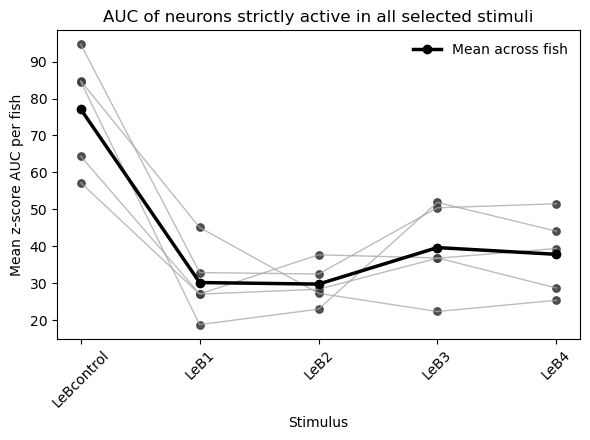

,fish_id,stimulus,mean_auc,n_shared_active_neurons
0,L684_f01,LeBcontrol,94.683863,112
1,L684_f01,LeB1,32.879474,112
2,L684_f01,LeB2,32.478932,112
3,L684_f01,LeB3,50.418566,112
4,L684_f01,LeB4,51.507941,112
5,L684_f07,LeBcontrol,84.515249,104
6,L684_f07,LeB1,18.792463,104
7,L684_f07,LeB2,22.966954,104
8,L684_f07,LeB3,51.870715,104
9,L684_f07,LeB4,44.108443,104


In [8]:
# Cell 08 - Mean AUC for neurons strictly active in the left position map.
# Edit this list (IDs or names) to choose a different shared-active comparison.
AUC_COMPARISON_STIMULI = [7, 3, 4, 5, 6]
auc_selection = at.resolve_selected_stimuli(AUC_COMPARISON_STIMULI, reference_fish['stimuli_id_map'],
                                           reference_fish['trial_aligned_traces_z_core'].keys())
auc_active_matrices = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data, fish_ids=fish_ids, stim_order=auc_selection['stimulus_ids'],
    fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'], motion_onset_s=timing['motion_onset_s'],
    tau_s=timing['tau_s'], active_fraction_threshold=0.10, min_epoch_s=1.0, min_active_reps=2,
    expected_reps=4, require_expected_reps=True,
)
auc_by_fish = []
for fish_id in fish_ids:
    fish = all_fish_data[fish_id]
    shared_active = auc_active_matrices[fish_id].loc[:, auc_selection['stimulus_ids']].all(axis=1).to_numpy()
    if not shared_active.any():
        print(f'{fish_id}: no neurons are strictly active in every selected stimulus.')
        continue
    auc_matrix = mfa.build_zscore_response_matrix_for_fish(
        fish['trial_aligned_traces_z_core'], auc_selection['stimulus_ids'], fish['stimuli_durations'],
        stimuli_id_map=fish['stimuli_id_map'], kept_neuron_indices=fish['kept_neuron_indices'],
        fps_2p=timing['fps_2p'], t_pre_s=timing['t_pre_s'], motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
    )
    auc_by_fish.append(pd.DataFrame({'fish_id': fish_id, 'stimulus': auc_selection['stimulus_labels'],
        'mean_auc': auc_matrix.loc[shared_active, auc_selection['stimulus_labels']].mean(axis=0).to_numpy(),
        'n_shared_active_neurons': int(shared_active.sum())}))
shared_active_auc_summary = pd.concat(auc_by_fish, ignore_index=True) if auc_by_fish else pd.DataFrame()
if shared_active_auc_summary.empty:
    print('No fish contributed shared-active neurons for the selected stimuli.')
else:
    fig, ax = plt.subplots(figsize=(max(6, len(auc_selection['stimulus_labels']) * 1.1), 4.5))
    stimulus_positions = np.arange(len(auc_selection['stimulus_labels']))
    for fish_id, values in shared_active_auc_summary.groupby('fish_id', sort=False):
        y = values.set_index('stimulus').loc[auc_selection['stimulus_labels'], 'mean_auc'].to_numpy()
        ax.plot(stimulus_positions, y, color='0.65', linewidth=1, alpha=0.75)
        ax.scatter(stimulus_positions, y, color='0.25', s=28, alpha=0.9)
    mean_auc = shared_active_auc_summary.groupby('stimulus')['mean_auc'].mean().reindex(auc_selection['stimulus_labels'])
    ax.plot(stimulus_positions, mean_auc, color='black', marker='o', linewidth=2.5, label='Mean across fish')
    ax.set(xticks=stimulus_positions, xticklabels=auc_selection['stimulus_labels'],
           ylabel='Mean z-score AUC per fish', xlabel='Stimulus',
           title='AUC of neurons strictly active in all selected stimuli')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
    display(shared_active_auc_summary)


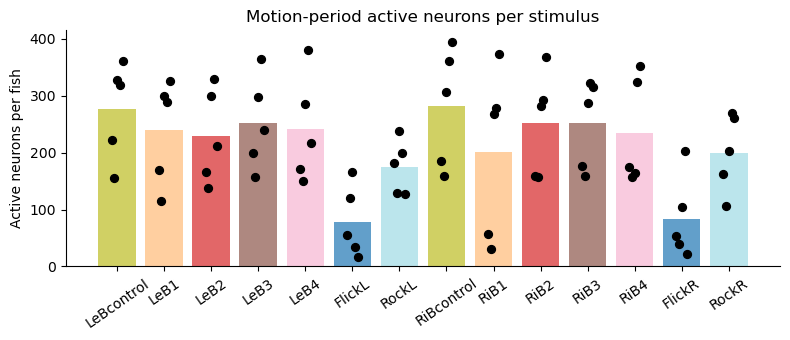

In [9]:
# Cell 09 - Motion-period active neurons per stimulus; each black point is one fish.
FIGSIZE = (8, 3.5)
motion_active_result = rsf.plot_motion_active_neuron_counts(
    all_fish_data, fish_ids, reference_fish, timing, stim_order, stimuli_colors,
    figsize=FIGSIZE, motion_onset_s=timing['motion_onset_s'], tau_s=timing['tau_s'],
)
active_neuron_counts = motion_active_result['counts']


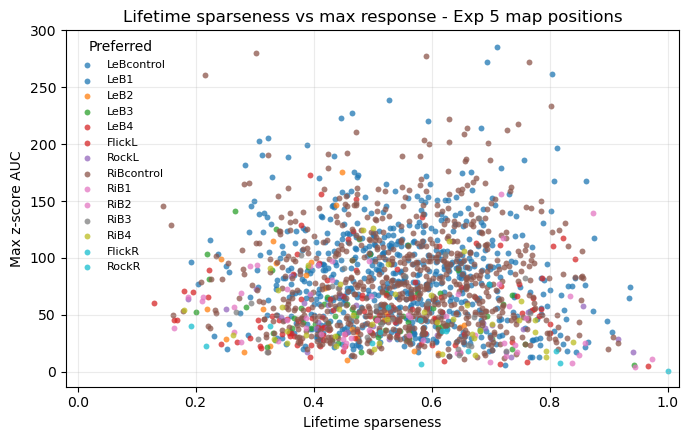

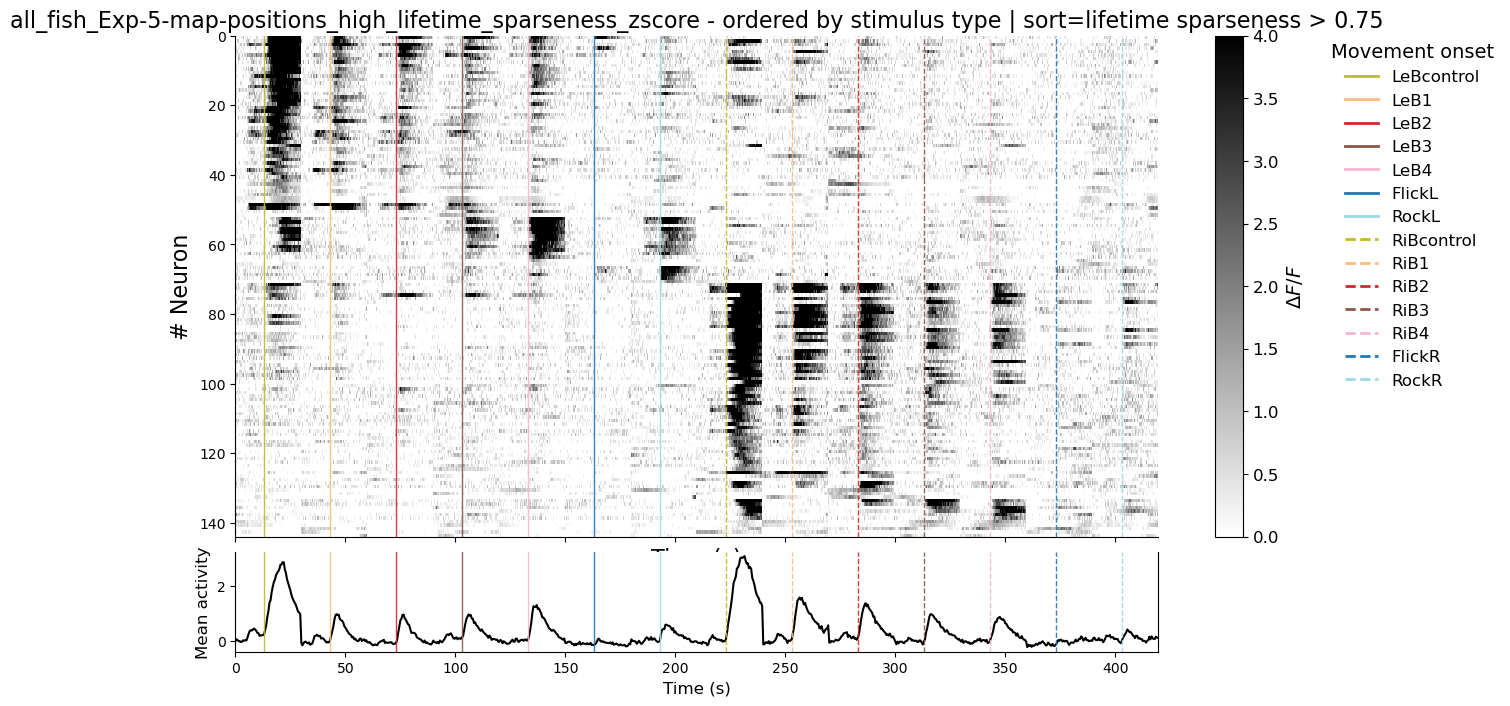

In [10]:
# Cell 10 - Lifetime sparseness and high-sparseness z-score raster.
SPARSENESS_FIGSIZE = (7, 4.5)
RASTER_FIGSIZE = (13, 8)
HIGH_LIFETIME_SPARSENESS = 0.75
sparseness_result = rsf.plot_lifetime_sparseness_analysis(
    all_fish_data, fish_ids, reference_fish, timing, stim_order, HIGH_LIFETIME_SPARSENESS,
    stimuli_colors, stimuli_linestyles, combine_mode='mean', sparseness_figsize=SPARSENESS_FIGSIZE,
    raster_figsize=RASTER_FIGSIZE, analysis_label=settings['analysis_label'],
)


C:\Users\larsch-lab\AppData\Local\Temp\ipykernel_5748\3553541948.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  heatmap_ax.set(


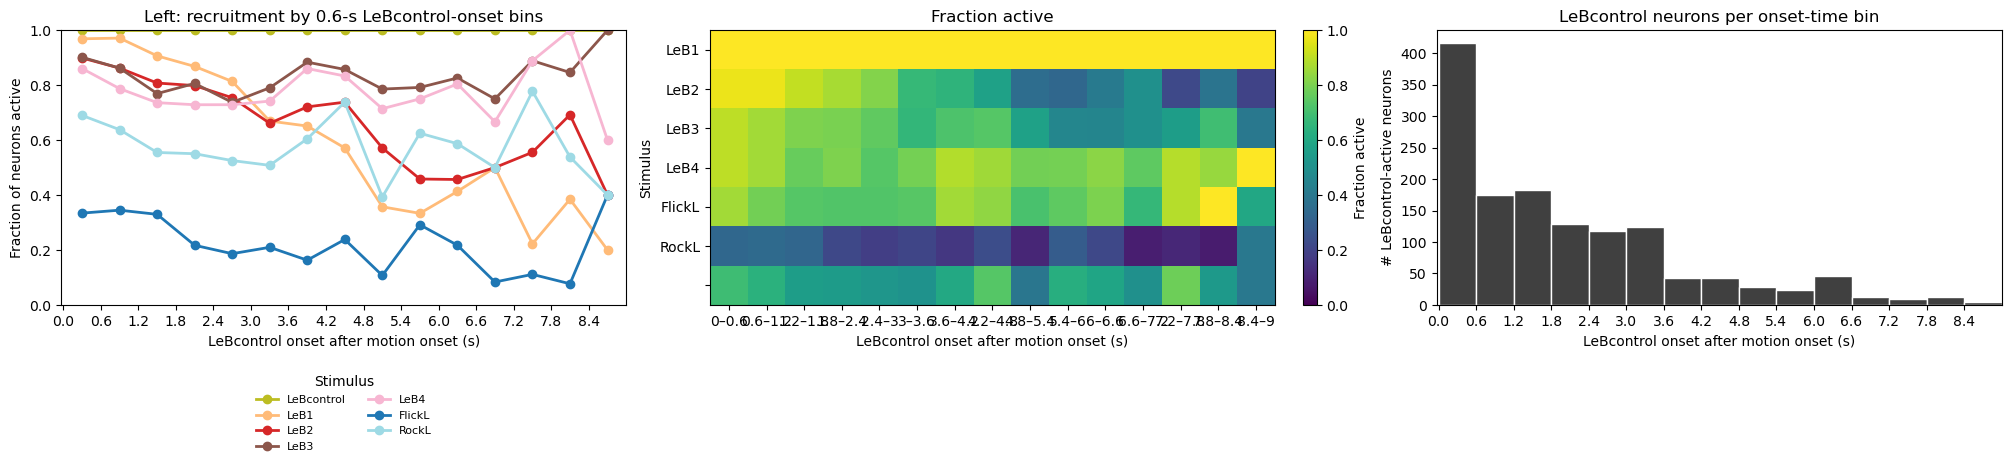

onset_bin,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
LeBcontrol,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
LeB1,0.968750,0.971264,0.906593,0.868217,0.813559,0.669355,0.651163,0.571429,0.357143,0.333333,0.413043,0.500000,0.222222,0.384615,0.2
LeB2,0.899038,0.862069,0.807692,0.798450,0.754237,0.661290,0.720930,0.738095,0.571429,0.458333,0.456522,0.500000,0.555556,0.692308,0.4
LeB3,0.901442,0.862069,0.769231,0.806202,0.737288,0.790323,0.883721,0.857143,0.785714,0.791667,0.826087,0.750000,0.888889,0.846154,1.0
LeB4,0.860577,0.787356,0.736264,0.728682,0.728814,0.741935,0.860465,0.833333,0.714286,0.750000,0.804348,0.666667,0.888889,1.000000,0.6
FlickL,0.334135,0.344828,0.329670,0.217054,0.186441,0.209677,0.162791,0.238095,0.107143,0.291667,0.217391,0.083333,0.111111,0.076923,0.4
RockL,0.689904,0.637931,0.554945,0.550388,0.525424,0.508065,0.604651,0.738095,0.392857,0.625000,0.586957,0.500000,0.777778,0.538462,0.4


In [13]:
# Cell 08 - Recruitment by reference-onset time.
# This uses the same strict active-neuron decisions as the reference-active raster.
REFERENCE_ONSET_TIME_BIN_S = 0.6  # Editable: width of measured post-motion onset-time bins.
REFERENCE_ONSET_MAX_TIME_S = 9.0  # Editable upper limit; bins span 0 s up to, but not including, this time.
RECRUITMENT_SIDES = ('left',)  # RiB by default; use ('left', 'right') to also plot LeB.

if REFERENCE_ONSET_TIME_BIN_S <= 0:
    raise ValueError('REFERENCE_ONSET_TIME_BIN_S must be positive.')
if REFERENCE_ONSET_MAX_TIME_S <= 0:
    raise ValueError('REFERENCE_ONSET_MAX_TIME_S must be positive.')

reference_onset_recruitment = {}
for side in RECRUITMENT_SIDES:
    if side not in REFERENCE_RASTER_SETTINGS:
        raise KeyError(f'Unknown side {side!r}; choose from {tuple(REFERENCE_RASTER_SETTINGS)}.')
    group = REFERENCE_RASTER_SETTINGS[side]
    selection = at.resolve_selected_stimuli(
        group['plot_stimuli'], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_raster'].keys(),
    )
    reference_selection = at.resolve_selected_stimuli(
        [group['reference_stimulus']], stimuli_id_map=reference_fish['stimuli_id_map'],
        available_stimuli=reference_fish['trial_aligned_traces_raster'].keys(),
    )
    reference_id = reference_selection['stimulus_ids'][0]
    reference_label = reference_selection['stimulus_labels'][0]

    pooled_rows = []
    for fish_id in fish_ids:
        fish = all_fish_data[fish_id]
        reference_key = reference_id if reference_id in fish['trial_aligned_traces_raster'] else str(reference_id)
        reference_raster = np.asarray(fish['trial_aligned_traces_raster'][reference_key], dtype=bool)
        duration = fish['stimuli_durations'][reference_label]
        motion_frame = int(np.clip(
            round((timing['t_pre_s'] + duration['static_before_sec']) * timing['fps_2p']),
            0, reference_raster.shape[1] - 1,
        ))
        active_by_frame = reference_raster.mean(axis=2) >= min_active_reps
        post_motion = active_by_frame[:, motion_frame:]
        first_active = np.full(reference_raster.shape[0], np.inf)
        has_active_frame = post_motion.any(axis=1)
        first_active[has_active_frame] = motion_frame + post_motion[has_active_frame].argmax(axis=1)

        active_matrix = reference_active_matrices[fish_id]
        reference_column = reference_id if reference_id in active_matrix.columns else str(reference_id)
        for neuron_id in np.flatnonzero(active_matrix[reference_column].to_numpy(dtype=bool)):
            if not np.isfinite(first_active[neuron_id]):
                continue  # A strict reference decision without a measurable post-motion onset.
            row = {
                'fish_id': fish_id, 'neuron_id': neuron_id, 'onset_frame': first_active[neuron_id],
                'onset_time_s': (first_active[neuron_id] - motion_frame) / timing['fps_2p'],
            }
            for stimulus_id, stimulus_label in zip(selection['stimulus_ids'], selection['stimulus_labels']):
                column = stimulus_id if stimulus_id in active_matrix.columns else str(stimulus_id)
                row[stimulus_label] = bool(active_matrix.iloc[neuron_id][column])
            pooled_rows.append(row)

    pooled_rows = pd.DataFrame(pooled_rows)
    if pooled_rows.empty:
        print(f'No reference-active neurons with measurable post-motion onsets for {side} ({reference_label}).')
        continue

    pooled_rows = pooled_rows.loc[
        (pooled_rows['onset_time_s'] >= 0) & (pooled_rows['onset_time_s'] < REFERENCE_ONSET_MAX_TIME_S)
    ].sort_values('onset_time_s', kind='stable').reset_index(drop=True)
    if pooled_rows.empty:
        print(f'No {reference_label}-active neurons have onsets between 0 and {REFERENCE_ONSET_MAX_TIME_S:g} s.')
        continue
    onset_bin_count = int(np.ceil(REFERENCE_ONSET_MAX_TIME_S / REFERENCE_ONSET_TIME_BIN_S))
    pooled_rows['onset_bin'] = np.floor(
        pooled_rows['onset_time_s'] / REFERENCE_ONSET_TIME_BIN_S
    ).astype(int)
    onset_bin_indices = np.arange(onset_bin_count)
    onset_bin_starts_s = onset_bin_indices * REFERENCE_ONSET_TIME_BIN_S
    onset_bin_ends_s = np.minimum(onset_bin_starts_s + REFERENCE_ONSET_TIME_BIN_S, REFERENCE_ONSET_MAX_TIME_S)
    onset_bin_centers_s = (onset_bin_starts_s + onset_bin_ends_s) / 2
    onset_bin_labels = [
        f'{start_s:g}–{end_s:g}' for start_s, end_s in zip(onset_bin_starts_s, onset_bin_ends_s)
    ]
    fraction_active = pooled_rows.groupby('onset_bin')[selection['stimulus_labels']].mean().reindex(
        onset_bin_indices
    )
    neurons_per_bin = pooled_rows.groupby('onset_bin').size().reindex(onset_bin_indices, fill_value=0)
    reference_onset_recruitment[side] = {
        'reference_label': reference_label, 'neurons': pooled_rows, 'fraction_active': fraction_active,
        'onset_bin_starts_s': onset_bin_starts_s, 'onset_bin_centers_s': onset_bin_centers_s,
        'onset_bin_labels': onset_bin_labels,
        'neurons_per_bin': neurons_per_bin,
    }

    fig, (line_ax, heatmap_ax, count_ax) = plt.subplots(1, 3, figsize=(20, 4.5), constrained_layout=True)
    for stimulus_label in selection['stimulus_labels']:
        line_ax.plot(
            onset_bin_centers_s, fraction_active[stimulus_label], marker='o', linewidth=2,
            color=stimuli_colors.get(stimulus_label), label=stimulus_label,
        )
    line_ax.set(
        xlabel=f'{reference_label} onset after motion onset (s)', ylabel='Fraction of neurons active',
        title=f'{side.capitalize()}: recruitment by {REFERENCE_ONSET_TIME_BIN_S:g}-s {reference_label}-onset bins',
        xticks=onset_bin_starts_s, ylim=(0, 1),
    )
    line_ax.set_xlim(-0.05 * REFERENCE_ONSET_TIME_BIN_S, REFERENCE_ONSET_MAX_TIME_S)
    line_ax.legend(title='Stimulus', frameon=False, fontsize=8, ncol=2,
                   bbox_to_anchor=(0.5, -0.22), loc='upper center')

    heatmap_values = fraction_active.T.to_numpy(dtype=float)
    image = heatmap_ax.imshow(heatmap_values, aspect='auto', vmin=0, vmax=1, cmap='viridis')
    heatmap_ax.set(
        xlabel=f'{reference_label} onset after motion onset (s)', ylabel='Stimulus',
        title='Fraction active', xticks=np.arange(onset_bin_count),
        xticklabels=onset_bin_labels,
        yticklabels=selection['stimulus_labels'],
    )
    fig.colorbar(image, ax=heatmap_ax, label='Fraction active')

    count_ax.bar(
        onset_bin_centers_s, neurons_per_bin.to_numpy(),
        width=onset_bin_ends_s - onset_bin_starts_s, align='center', color='0.25', edgecolor='white',
    )
    count_ax.set(
        xlabel=f'{reference_label} onset after motion onset (s)', ylabel=f'# {reference_label}-active neurons',
        title=f'{reference_label} neurons per onset-time bin', xticks=onset_bin_starts_s,
    )
    count_ax.set_xlim(-0.05 * REFERENCE_ONSET_TIME_BIN_S, REFERENCE_ONSET_MAX_TIME_S)
    plt.show()
    display(fraction_active.T)


In [11]:
# Cell 11 - Optional reviewed-run report.
# Save this notebook before enabling REPORT_SETTINGS['save_report'].
notebook_path = repo_root / 'scripts' / 'calcium_analysis' / 'Exp_5_map_positions' / '01_all_fish_raster.ipynb'
report_result = rsf.save_analysis_report_run(
    settings=settings, report_settings=REPORT_SETTINGS, analysis_path=analysis_path,
    tables={'active_neuron_counts': active_neuron_counts,
            'shared_active_auc_summary': shared_active_auc_summary},
    notebook_path=notebook_path,
)


Report saving is off. Set REPORT_SETTINGS['save_report'] = True to save this run.
